**Dataset Selection:**  
**Data set Description described in another document “Drug Response Classification”**   
**Task 1: Exploratory Data Analysis (EDA)**  
1.	Load the dataset and perform fundamental data exploration.   
2.	Utilize histograms, box plots, or density plots to understand feature distributions.  
3.	Investigate feature correlations to discern relationships within the data.


1.	Load the dataset and perform fundamental data exploration.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('Pharma_Industry (2).csv')
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [ ]:
df.shape

(500, 6)

In [ ]:
df.size

3000

In [ ]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [ ]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [ ]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


2.	Utilize histograms, box plots, or density plots to understand feature distributions.

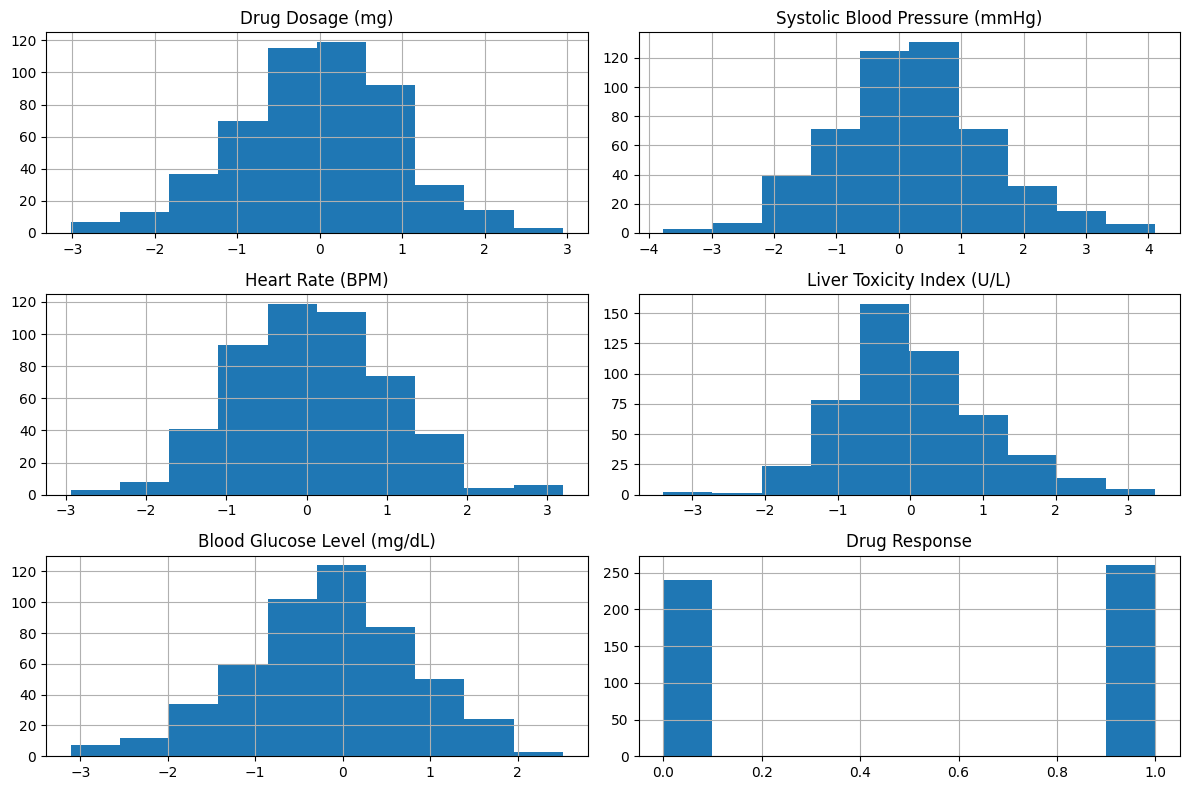

In [ ]:
#Histograms
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

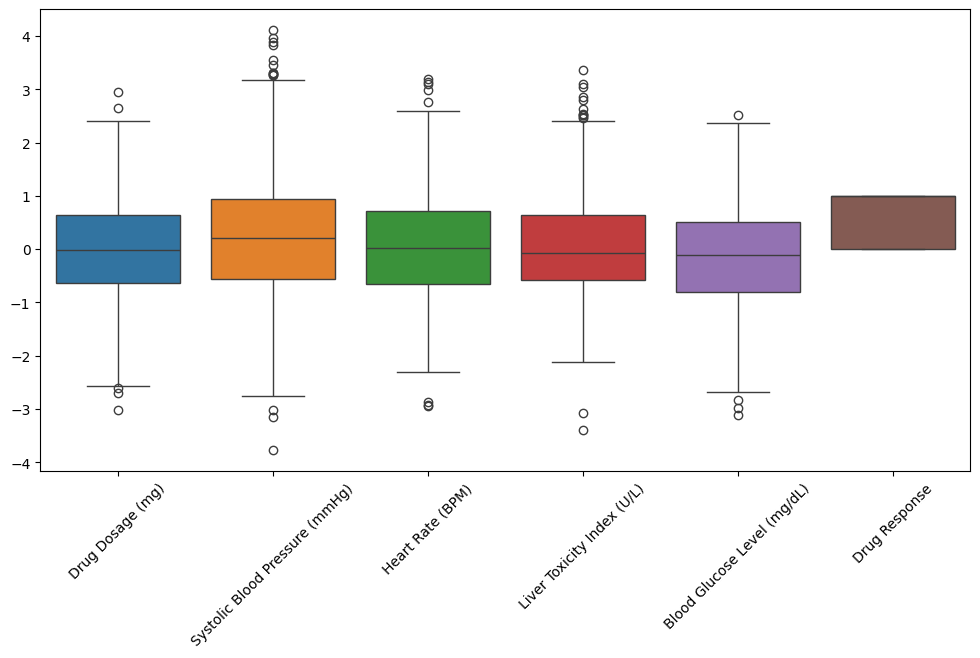

In [ ]:
#Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

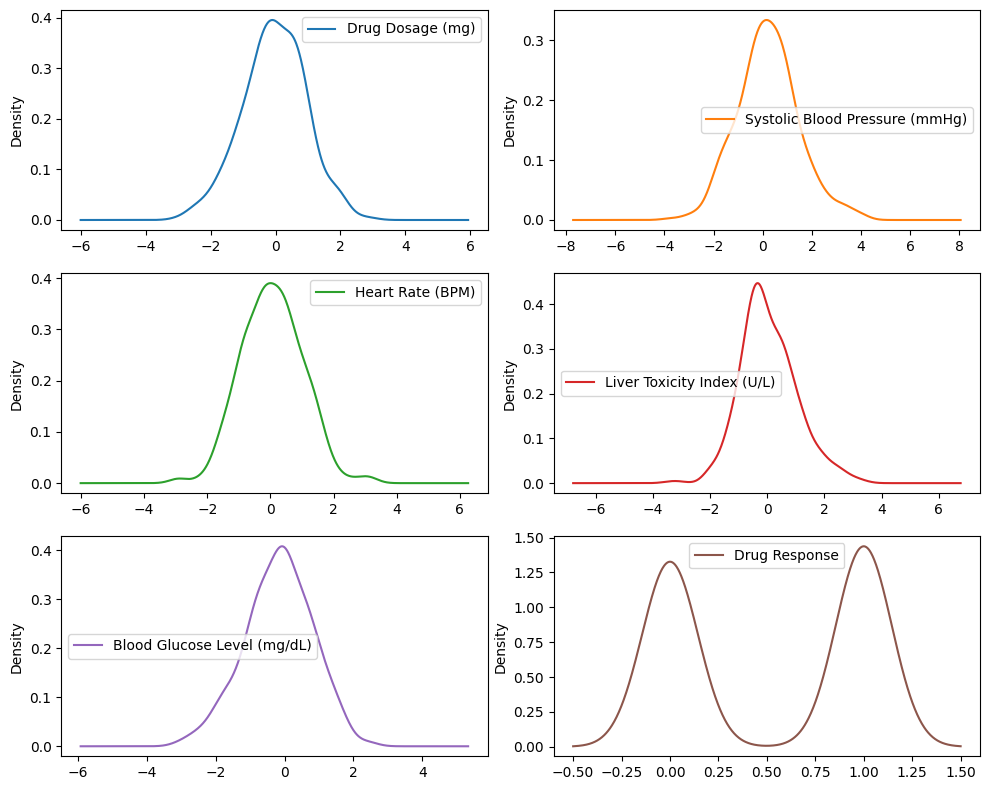

In [ ]:
#Density plot
df.plot(kind='density', subplots=True, layout=(3,2), figsize=(10,8), sharex=False)
plt.tight_layout()
plt.show()

3.	Investigate feature correlations to discern relationships within the data.

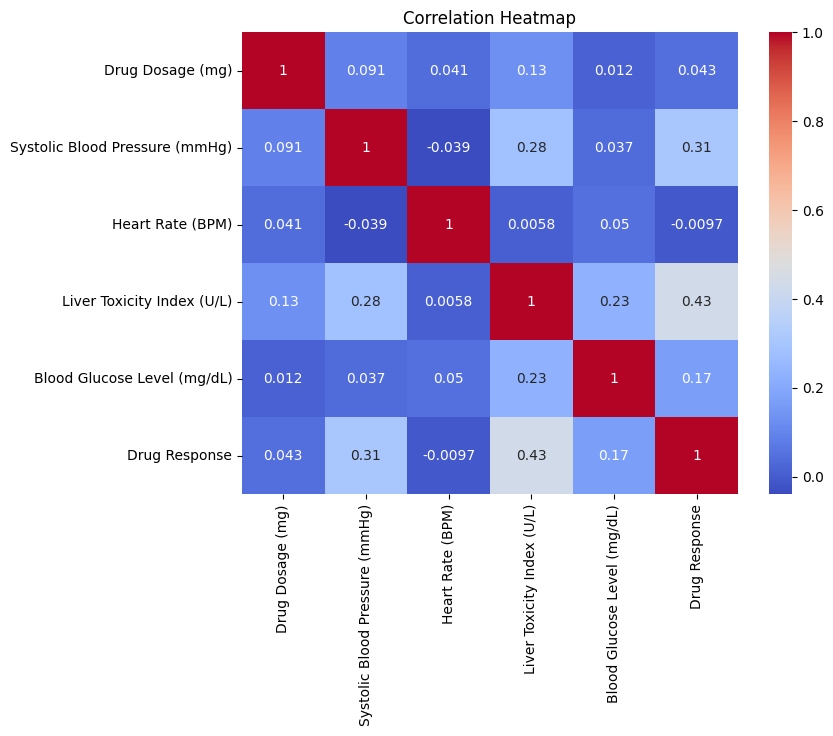

In [ ]:
#Het map
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Task 2: Data Preprocessing**  
1.	Encode categorical variables if necessary.


In [ ]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


2.	Split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
# Features (X) and Target (y)
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
# Check the shape of the split datasets
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (400, 5)
Testing Features: (100, 5)
Training Labels: (400,)
Testing Labels: (100,)


**Task 3: Data Visualization**  
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.


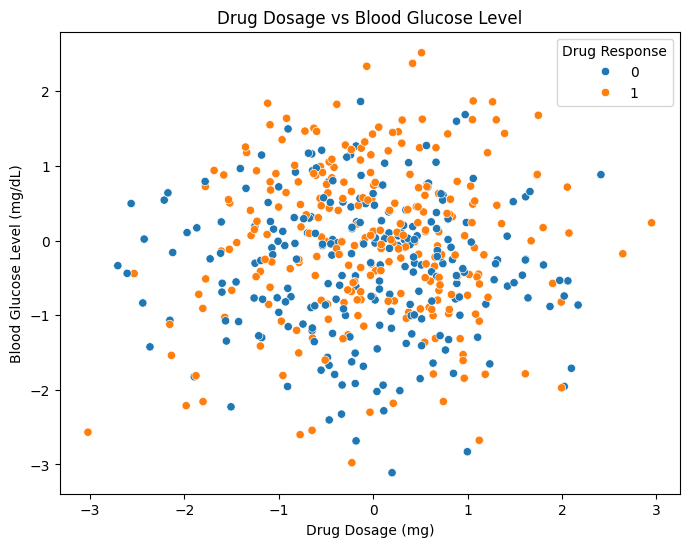

In [ ]:
#scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Drug Dosage (mg)', y='Blood Glucose Level (mg/dL)', hue='Drug Response', data=df)
plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()

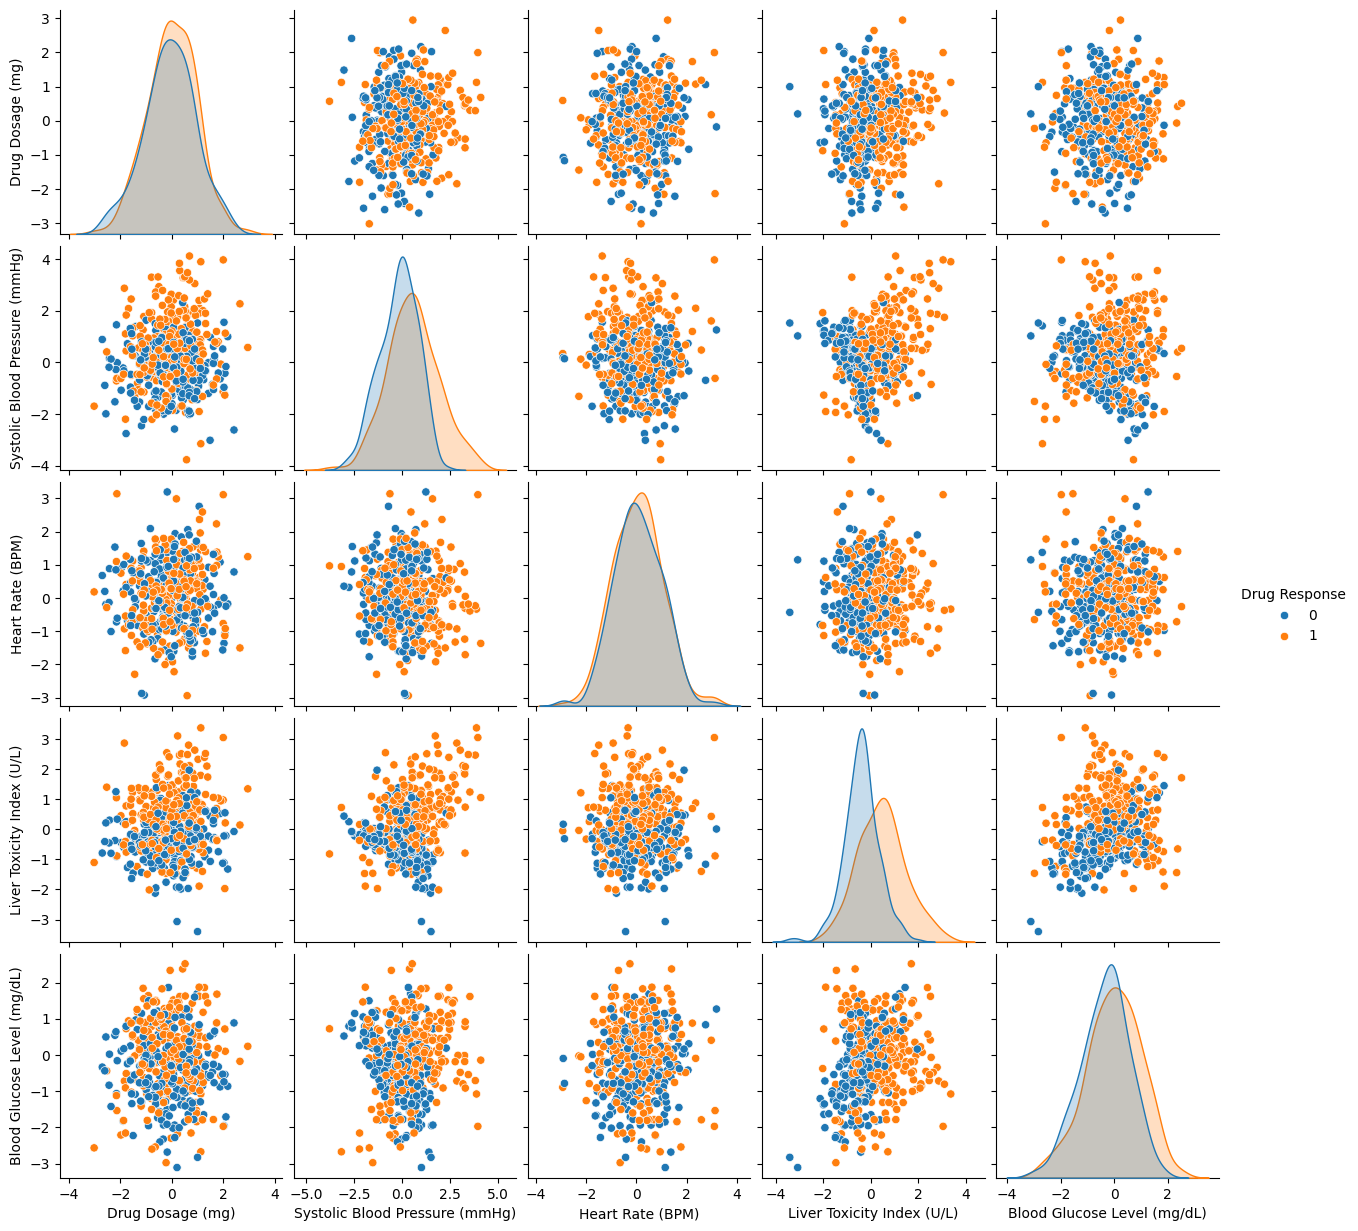

In [ ]:
#pair plot
sns.pairplot(df, hue='Drug Response')
plt.show()

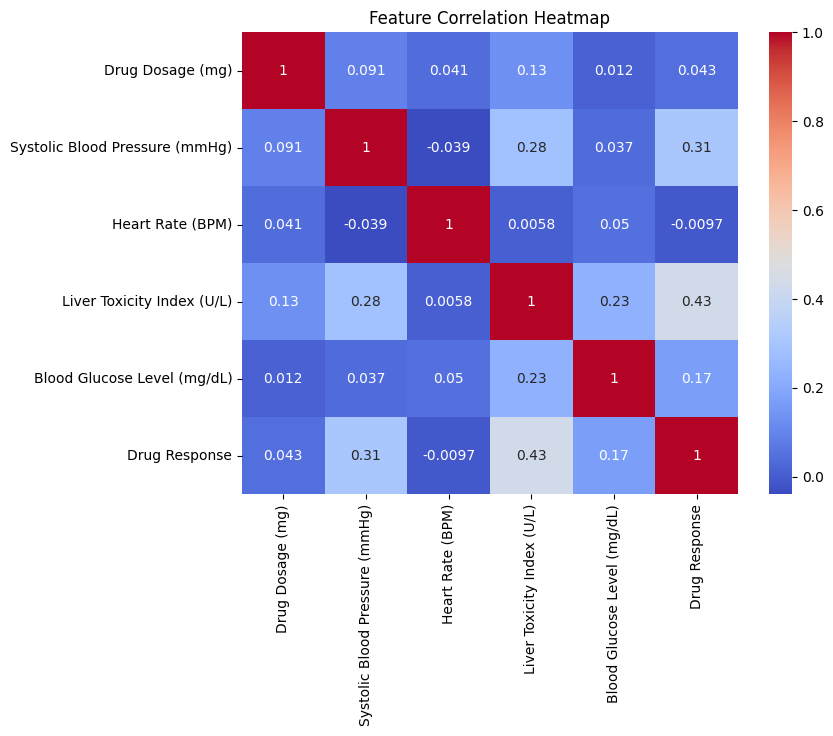

In [ ]:
#Heat map
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

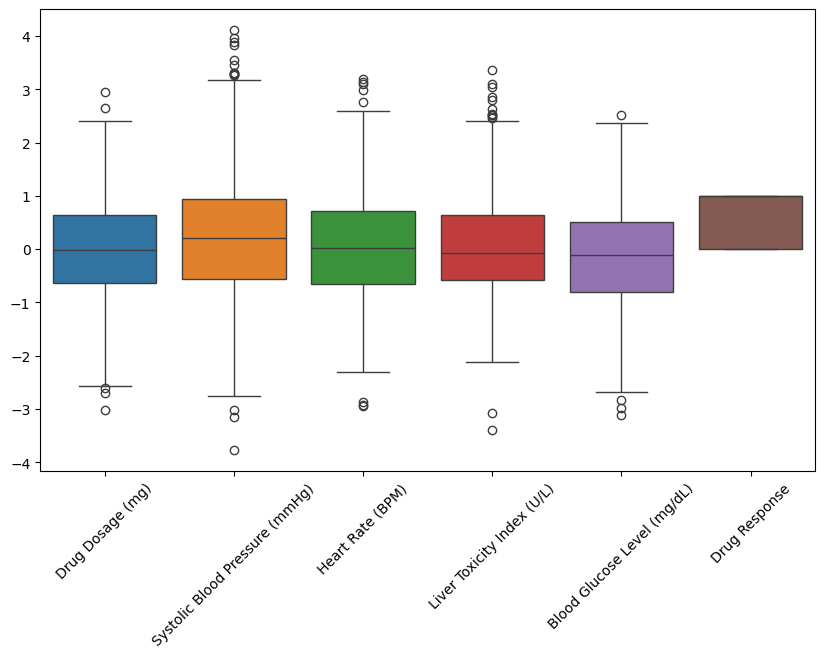

In [ ]:
#Box plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

2.	Visualize class distributions to gauge dataset balance or imbalance.

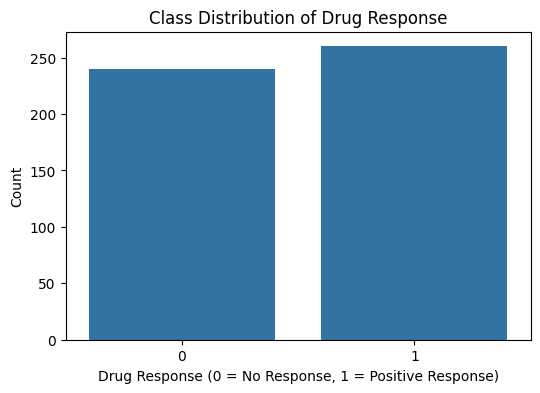

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Drug Response', data=df)
plt.title("Class Distribution of Drug Response")
plt.xlabel("Drug Response (0 = No Response, 1 = Positive Response)")
plt.ylabel("Count")
plt.show()

In [ ]:
df['Drug Response'].value_counts()

,count
Drug Response,
1,260
0,240


**Task 4: SVM Implementation**  
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.


In [ ]:
#import svm
from sklearn.svm import SVC
#crate svm classifier
svm_model = SVC(kernel='linear', random_state=42)
#train the model
svm_model.fit(X_train, y_train)
#make prediction
y_pred = svm_model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 0
 0 1 1 0 1 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 1 1
 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1]


2.	Train the SVM model on the training data.

In [ ]:
# Train the SVM model
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
# Create the SVM classifier
svm_model = SVC(kernel='linear', random_state=42)
# Train the model
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [ ]:
#import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
#evaluation matrics
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)
#classification metrics
print(classification_report(y_test, y_pred))
#confusion matrix
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.78
Precision: 0.84
Recall: 0.75
F1-Score: 0.7924528301886793
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100

[[36  8]
 [14 42]]


**Task 5: Visualization of SVM Results**      

1.	Visualize classification results on the testing data.


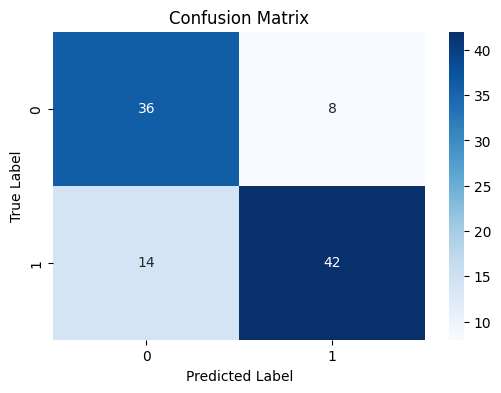

In [ ]:
#confusion matrix heatmap
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
#Actual v/s Predicted values
results = pd.DataFrame({'Actual': y_test,'Predicted': y_pred})
results.head(10)

,Actual,Predicted
361,0,0
73,0,0
374,1,0
155,1,0
104,0,0
394,0,0
377,1,0
124,1,0
68,0,0
450,1,0


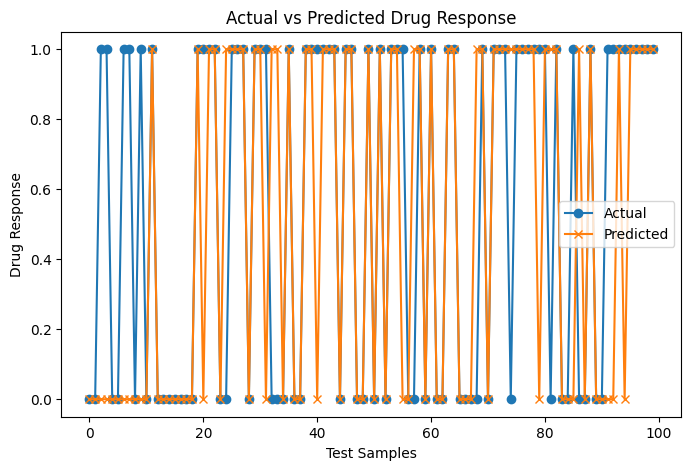

In [ ]:
#plot Actual v/s Predicted values
plt.figure(figsize=(8,5))
plt.plot(results['Actual'].values, label='Actual', marker='o')
plt.plot(results['Predicted'].values, label='Predicted', marker='x')
plt.title("Actual vs Predicted Drug Response")
plt.xlabel("Test Samples")
plt.ylabel("Drug Response")
plt.legend()
plt.show()

**Task 6: Parameter Tuning and Optimization**   
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
#define hyperparameters
param_grid = {'C': [0.1, 1, 10, 100],'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],'gamma': ['scale', 'auto']}
#Apply Grid Search
grid = GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

In [ ]:
#Display best parameters
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.74


In [ ]:
#evaluate the best model
from sklearn.metrics import accuracy_score, classification_report
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.79      0.84      0.81        44
           1       0.87      0.82      0.84        56

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



**Task 7: Comparison and Analysis**   
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Kernel: {kernel}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("-" * 30)

Kernel: linear
Accuracy: 0.78
------------------------------
Kernel: poly
Accuracy: 0.69
------------------------------
Kernel: rbf
Accuracy: 0.82
------------------------------


In [ ]:
#compare accuracy
from sklearn.metrics import accuracy_score
results = []
for kernel in ['linear', 'poly', 'rbf']:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({'Kernel': kernel,'Accuracy': accuracy_score(y_test, y_pred)})
comparison = pd.DataFrame(results)
comparison

,Kernel,Accuracy
0,linear,0.78
1,poly,0.69
2,rbf,0.82


2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

**Strengths of SVM**:   
SVM performs well for binary classification problems such as Drug Response Classification (0 = No Response, 1 = Positive Response).  
It can effectively separate classes when the data has a clear decision boundary.  
SVM is robust to high-dimensional data and works well even with a moderate number of features.     
Using different kernels (Linear, Polynomial, and RBF) allows the model to capture both linear and non-linear relationships.    
SVM generally provides good generalization performance and helps reduce overfitting by maximizing the margin between classes.   
**Weaknesses of SVM**  
SVM is sensitive to the choice of hyperparameters such as kernel, C, and gamma.  
It may require feature scaling for optimal performance.   
Training time increases as the dataset size becomes larger.   
The model is less interpretable compared to decision trees or logistic regression.   
Selecting the appropriate kernel often requires experimentation and parameter tuning.          
 **Analysis Based on EDA and Visualizations**   
Histograms and box plots showed the distribution of numerical features and helped identify potential outliers.   
The correlation heatmap indicated the relationships among the features and helped understand feature importance.   
The class distribution plot showed whether the dataset was balanced or imbalanced, which can influence classification performance.   
Scatter plots and pair plots helped visualize the separation between the two drug response classes.    
After comparing different kernels, the kernel with the highest accuracy (e.g., Linear, Polynomial, or RBF based on your results) was selected as the best-performing model.

3.	Discuss practical implications of SVM in real-world classification tasks.

**Practical Implications of SVM in Real-World Classification Tasks**    
**Healthcare:** SVM is widely used to predict diseases, classify medical images, and identify patient responses to treatments, such as drug response classification.  
**Spam Email Detection:** SVM helps classify emails as spam or non-spam based on their content.  
**Image Recognition:** It is used in facial recognition, object detection, and handwritten digit classification.  
**Financial Fraud Detection:** SVM can detect fraudulent transactions by identifying unusual patterns in financial data.   
**Text Classification:** It is applied in sentiment analysis, document categorization, and news classification.   
**Bioinformatics:** SVM is used to classify genes, proteins, and biological samples for medical research.